In [9]:
# Cell 0: Fix working directory — run this first, only once
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print('Working directory:', os.getcwd())

Working directory: /Users/spartan/Desktop/Spring 2026/257 - ML/CardioWatch


In [10]:
# Cell 1: Load and plot a sample ECG
import wfdb
import matplotlib.pyplot as plt
import numpy as np
import glob
import sys
sys.path.insert(0, '.')
from src.preprocessing.ecg_filter import bandpass_filter

data_dir = 'data/raw/classification-of-12-lead-ecgs-the-physionetcomputing-in-cardiology-challenge-2020-1.0.2/training/cpsc_2018'
hea_files = glob.glob(f'{data_dir}/**/*.hea', recursive=True)
record_path = hea_files[0].replace('.hea', '')
print('Using record:', record_path)

record = wfdb.rdrecord(record_path)
print('Sampling rate:', record.fs, 'Hz')
print('Leads:', record.sig_name)
print('Signal shape:', record.p_signal.shape)
print('Duration:', record.p_signal.shape[0] / record.fs, 'seconds')

Using record: data/raw/classification-of-12-lead-ecgs-the-physionetcomputing-in-cardiology-challenge-2020-1.0.2/training/cpsc_2018/g6/A5669
Sampling rate: 500 Hz
Leads: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Signal shape: (5000, 12)
Duration: 10.0 seconds


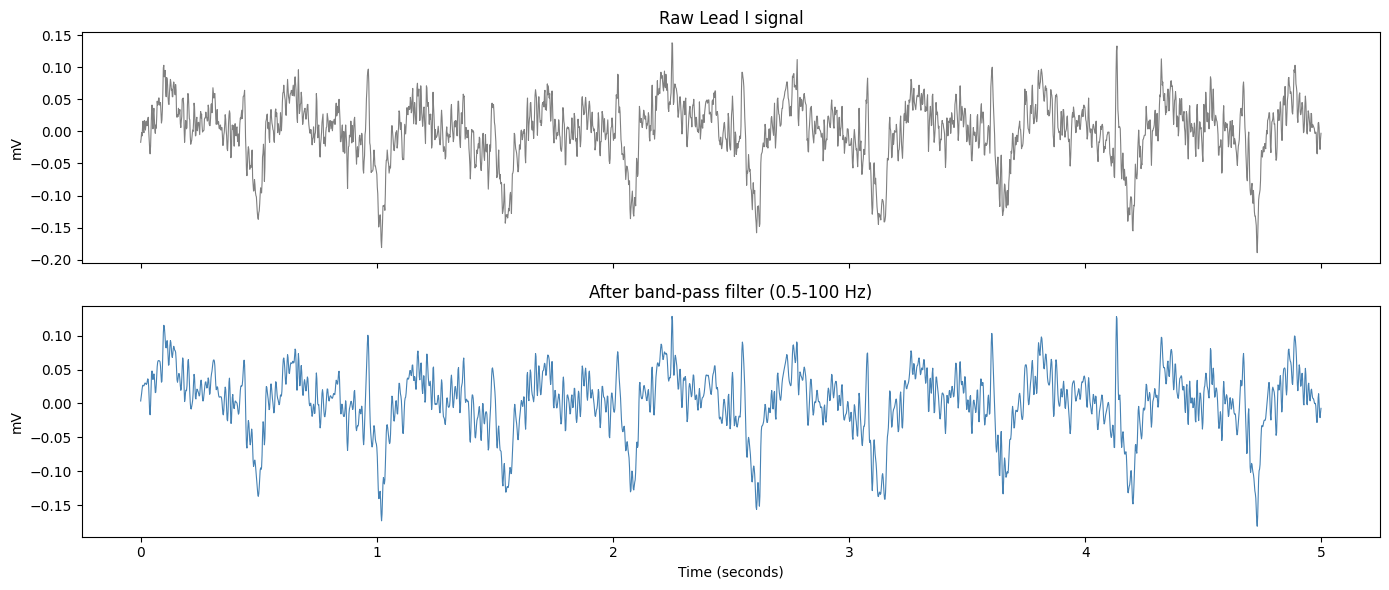

In [11]:
# Cell 2: Plot raw vs filtered signal
lead_names = [n.strip().upper() for n in record.sig_name]
lead_i_idx = lead_names.index('I') if 'I' in lead_names else 0
raw = record.p_signal[:, lead_i_idx]

fs = record.fs
filtered = bandpass_filter(raw, 0.5, 100.0, fs=fs)

# Plot first 5 seconds
t = np.arange(5 * fs) / fs
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
ax1.plot(t, raw[:5*fs], color='gray', linewidth=0.8)
ax1.set_title('Raw Lead I signal')
ax1.set_ylabel('mV')
ax2.plot(t, filtered[:5*fs], color='steelblue', linewidth=0.8)
ax2.set_title('After band-pass filter (0.5-100 Hz)')
ax2.set_ylabel('mV')
ax2.set_xlabel('Time (seconds)')
plt.tight_layout()
os.makedirs('docs', exist_ok=True)
plt.savefig('docs/ecg_raw_vs_filtered.png', dpi=150)
plt.show()

In [12]:
# Cell 3: Check signal quality across multiple recordings
import pandas as pd

hea_files_20 = glob.glob(f'{data_dir}/**/*.hea', recursive=True)[:20]
records = [f.replace('.hea', '') for f in hea_files_20]

stats = []
for rec in records:
    try:
        r = wfdb.rdrecord(rec)
        sig = r.p_signal[:, 0]
        stats.append({
            'record': os.path.basename(rec),
            'duration_s': round(len(sig) / r.fs, 1),
            'fs': r.fs,
            'std': round(float(np.std(sig)), 4),
            'has_nan': bool(np.isnan(sig).any())
        })
    except Exception as e:
        print(f'Could not load {rec}: {e}')

df_stats = pd.DataFrame(stats)
print(df_stats)
print('\nDurations (seconds):', df_stats['duration_s'].describe())

   record  duration_s   fs     std  has_nan
0   A5669        10.0  500  0.0479    False
1   A5641        10.0  500  0.1401    False
2   A5899        10.0  500  0.0907    False
3   A5127        23.0  500  0.0805    False
4   A5133        10.0  500  0.1818    False
5   A5655        14.0  500  0.0790    False
6   A5866        10.0  500  0.0885    False
7   A5872        17.0  500  0.0697    False
8   A5682        21.0  500  0.1367    False
9   A5696        14.2  500  0.0675    False
10  A5319        15.0  500  0.0558    False
11  A5325        31.7  500  0.0982    False
12  A5443        10.0  500  0.1398    False
13  A5457        28.6  500  0.1240    False
14  A5331        47.0  500  0.1184    False
15  A5480        29.0  500  0.1076    False
16  A5494        12.4  500  0.1012    False
17  A5279        23.0  500  0.1050    False
18  A5251        22.0  500  0.1325    False
19  A5537        12.0  500  0.1038    False

Durations (seconds): count    20.000000
mean     18.495000
std       9.7978